# 06 — 逐名问卷矩阵新增实验

这个 notebook 专门放新增的个体层面分析。输入文件是 `data/processed/问卷数据_文本版.xlsx`，核心样本为通过筛选后的 32 名女性在校大学生。

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
pd.set_option("display.max_colwidth", 120)

## 1. 读取逐名文本版数据并生成去身份化得分表

In [2]:
from src.analysis import (
    mann_whitney_group_table,
    participant_scale_summary,
    spearman_correlation_matrix,
    spearman_correlation_table,
)
from src.data_loader import load_participant_survey, question_column
from src.participant_analysis import build_participant_scores
from src.preprocessing import SLIDER_CONSTRUCTS

participants = load_participant_survey(ROOT / "data" / "processed" / "问卷数据_文本版.xlsx")
participant_scores = build_participant_scores(participants)

print("核心逐名样本 N =", len(participants))
display(participant_scores.head())

核心逐名样本 N = 32


,respondent_no,age,exercise_frequency,campus_gym_use,strength_training_experience,avoidance_frequency,avoidance_frequency_score,free_weight_user,systematic_strength_training,spatial_pressure,media_internalization,training_self_efficacy,intervention_preference
1,2,21-23岁,每周一次,是,有一点尝试，但不系统,有时,3,False,False,3.300000,3.366667,3.0,3.366667
2,3,18-20岁,每周一次,是,完全没有,经常,4,False,False,4.733333,3.033333,2.1,3.833333
3,4,18-20岁,每周4-5次,是,有一点尝试，但不系统,经常,4,False,False,4.150000,3.266667,4.1,4.266667
4,5,18-20岁,每周2-3次,是,完全没有,有时,3,False,False,3.700000,1.000000,3.0,3.300000
5,6,18-20岁,几乎不运动,否,完全没有,从未,1,False,False,3.283333,3.666667,3.5,3.666667


## 2. 构念得分与 Cronbach's alpha

空间压迫/训练焦虑和社交媒体审美内化可以解释为短量表；干预偏好三题是不同干预方案的偏好题组，不作严格量表信度解释。

In [3]:
item_columns = {
    construct: [question_column(participants, q_num) for q_num in q_nums]
    for construct, q_nums in SLIDER_CONSTRUCTS.items()
}
scale_summary = participant_scale_summary(participants, item_columns)
display(scale_summary[["construct", "item_count", "n", "mean", "sd", "min", "max", "alpha"]].round(3))

,construct,item_count,n,mean,sd,min,max,alpha
0,空间压迫/训练焦虑,6,32,3.716,0.766,1.383,5.0,0.808
1,社交媒体审美内化,3,32,2.659,0.930,1.000,5.0,0.760
2,训练自我效能,1,32,3.491,0.939,1.500,5.0,NaN
3,干预偏好指数,3,32,3.977,0.538,2.667,5.0,-0.057


## 3. 自由重量区回避频率编码检查

In [4]:
display(
    participant_scores["avoidance_frequency"]
    .value_counts()
    .rename_axis("avoidance_frequency")
    .reset_index(name="count")
)
display(participant_scores[["avoidance_frequency", "avoidance_frequency_score"]].head(10))

,avoidance_frequency,count
0,有时,10
1,经常,6
2,总是,6
3,从未,5
4,很少,5


,avoidance_frequency,avoidance_frequency_score
1,有时,3
2,经常,4
3,经常,4
4,有时,3
5,从未,1
6,从未,1
7,从未,1
8,很少,2
9,很少,2
10,从未,1


## 4. Spearman 相关实验

In [5]:
corr_variables = {
    "空间压迫/训练焦虑": "spatial_pressure",
    "社交媒体审美内化": "media_internalization",
    "训练自我效能": "training_self_efficacy",
    "干预偏好指数": "intervention_preference",
    "自由重量区回避频率": "avoidance_frequency_score",
}
correlations = spearman_correlation_table(participant_scores, corr_variables)
display(correlations.assign(
    spearman_rho=lambda d: d["spearman_rho"].round(3),
    p=lambda d: d["p"].round(4),
))

,x,y,n,spearman_rho,p
0,空间压迫/训练焦虑,社交媒体审美内化,32,0.405,0.0216
1,空间压迫/训练焦虑,训练自我效能,32,-0.021,0.9113
2,空间压迫/训练焦虑,干预偏好指数,32,0.671,0.0000
3,空间压迫/训练焦虑,自由重量区回避频率,32,0.652,0.0001
4,社交媒体审美内化,训练自我效能,32,0.145,0.4275
5,社交媒体审美内化,干预偏好指数,32,0.386,0.0290
6,社交媒体审美内化,自由重量区回避频率,32,0.310,0.0843
7,训练自我效能,干预偏好指数,32,0.265,0.1434
8,训练自我效能,自由重量区回避频率,32,-0.107,0.5617
9,干预偏好指数,自由重量区回避频率,32,0.455,0.0089


## 5. Spearman 相关矩阵与热力图

,空间压迫/训练焦虑,社交媒体审美内化,训练自我效能,干预偏好指数,自由重量区回避频率
空间压迫/训练焦虑,1.000,0.405,-0.021,0.671,0.652
社交媒体审美内化,0.405,1.000,0.145,0.386,0.310
训练自我效能,-0.021,0.145,1.000,0.265,-0.107
干预偏好指数,0.671,0.386,0.265,1.000,0.455
自由重量区回避频率,0.652,0.310,-0.107,0.455,1.000


E:\Project\1808论文\report\figures\survey_spearman_correlations.png


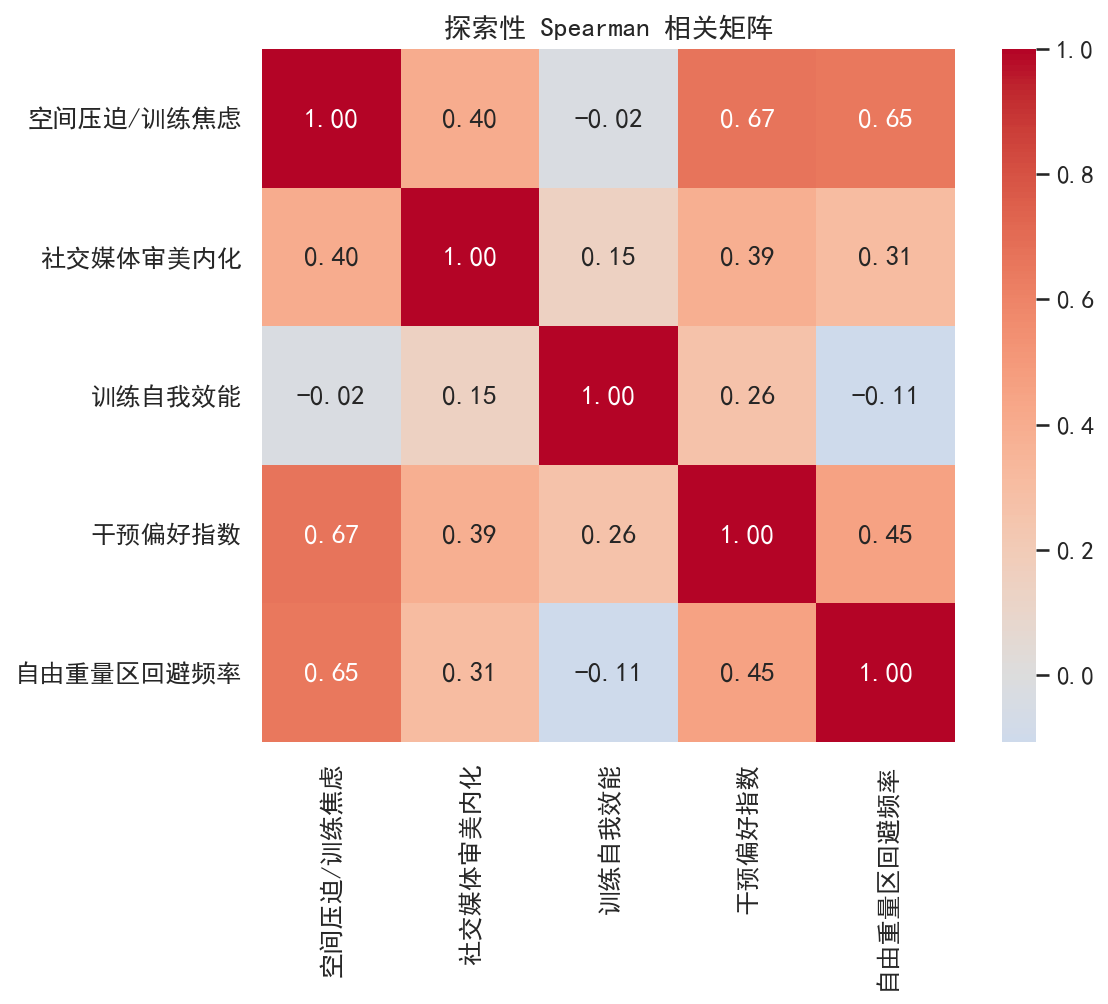

In [6]:
from src.visualization import correlation_heatmap

corr_matrix = spearman_correlation_matrix(participant_scores, corr_variables)
display(corr_matrix.round(3))

fig_dir = ROOT / "report" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
fig = correlation_heatmap(corr_matrix, title="探索性 Spearman 相关矩阵")
fig.savefig(fig_dir / "survey_spearman_correlations.png", dpi=200)
print(fig_dir / "survey_spearman_correlations.png")

## 6. Mann--Whitney 组间比较实验

In [7]:
group_comparisons = pd.concat(
    [
        mann_whitney_group_table(
            participant_scores,
            "free_weight_user",
            corr_variables,
            "最常使用自由重量区",
        ),
        mann_whitney_group_table(
            participant_scores,
            "systematic_strength_training",
            corr_variables,
            "有系统力量训练经验",
        ),
    ],
    ignore_index=True,
)
display(group_comparisons.assign(
    yes_mean=lambda d: d["yes_mean"].round(2),
    yes_sd=lambda d: d["yes_sd"].round(2),
    no_mean=lambda d: d["no_mean"].round(2),
    no_sd=lambda d: d["no_sd"].round(2),
    p=lambda d: d["p"].round(4),
))

,group,variable,yes_n,yes_mean,yes_sd,no_n,no_mean,no_sd,mann_whitney_u,p
0,最常使用自由重量区,空间压迫/训练焦虑,5,2.60,1.05,27,3.92,0.50,16.0,0.0081
1,最常使用自由重量区,社交媒体审美内化,5,2.08,0.68,27,2.77,0.94,34.5,0.0914
2,最常使用自由重量区,训练自我效能,5,3.88,0.76,27,3.42,0.96,86.0,0.3464
3,最常使用自由重量区,干预偏好指数,5,3.77,0.28,27,4.02,0.57,43.5,0.2220
4,最常使用自由重量区,自由重量区回避频率,5,1.40,0.55,27,3.41,1.19,10.0,0.0024
5,有系统力量训练经验,空间压迫/训练焦虑,8,3.18,1.03,24,3.90,0.58,56.5,0.0896
6,有系统力量训练经验,社交媒体审美内化,8,2.03,0.89,24,2.87,0.86,47.5,0.0366
7,有系统力量训练经验,训练自我效能,8,3.82,0.89,24,3.38,0.95,117.5,0.3570
8,有系统力量训练经验,干预偏好指数,8,3.93,0.47,24,3.99,0.57,83.5,0.6011
9,有系统力量训练经验,自由重量区回避频率,8,1.88,0.83,24,3.50,1.22,28.0,0.0026


## 7. 保存新增实验输出

In [8]:
out_dir = ROOT / "data" / "processed"
participant_scores.to_csv(out_dir / "survey_participant_scores.csv", index=False, encoding="utf-8-sig")
scale_summary.to_csv(out_dir / "survey_participant_scale_summary.csv", index=False, encoding="utf-8-sig")
correlations.to_csv(out_dir / "survey_spearman_correlations.csv", index=False, encoding="utf-8-sig")
corr_matrix.to_csv(out_dir / "survey_spearman_matrix.csv", encoding="utf-8-sig")
group_comparisons.to_csv(out_dir / "survey_group_comparisons.csv", index=False, encoding="utf-8-sig")
print(out_dir)

E:\Project\1808论文\data\processed
